In [189]:
import numpy as np
import matplotlib.pyplot as plt
from objprint import op
from PIL import Image
from tqdm import tqdm
import cv2
import sys

sys.path.append("/home/arno/Projects/Pint3D/print_ngp/util")

import printer.printerICM as icm


In [227]:
loaded_data = np.load("ColorWheel/volumeWheel/colorWheelVolume.npz")
volume = loaded_data['volume']
volume.shape

(357, 595, 1785, 4)

In [133]:
volume[0].max()

np.float32(1.0)

标识码 50单位长度



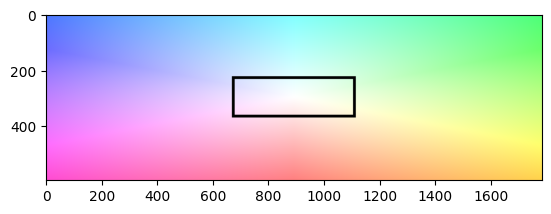

In [206]:
# 和之前一样的处理方式，但是不用超分了：顶面加一个空心方框
image = volume[0]
# 获取图像尺寸
height, width, _ = image.shape

# 定义方框的尺寸（可以根据需要调整）
box_height = height // 4  # 高度为图像高度的1/4
box_width = width // 4    # 宽度为图像宽度的1/4

# 计算方框的左上角坐标，使其居中
top = (height - box_height) // 2
left = (width - box_width) // 2

# 计算方框的右下角坐标
bottom = top + box_height
right = left + box_width

# 定义线条宽度
line_width = 10
# 创建黑色线条 (0,0,0,100)
black_color = np.array([0, 0, 0, 1], dtype=image.dtype)

# 绘制上边框
image[top:top+line_width, left:right] = black_color

# 绘制下边框
image[bottom-line_width:bottom, left:right] = black_color

# 绘制左边框
image[top:bottom, left:left+line_width] = black_color

# 绘制右边框
image[top:bottom, right-line_width:right] = black_color
plt.imshow(image)
plt.show()



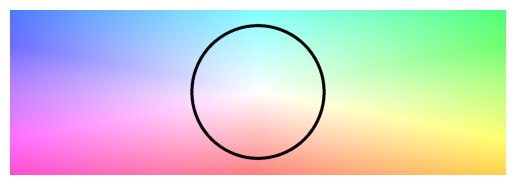

In [228]:
# 表面10层没有任何白色：顶面加一个空心圆圈

# 假设volume[0]是你的图像
image = volume[0]

# 获取图像尺寸
height, width, _ = image.shape

# 定义圆的参数
center = (width // 2, height // 2)
radius = min(height, width) // 5 *2
line_width = 10  # 线条宽度

# 定义黑色线条 (0,0,0,255) - OpenCV使用BGR格式
black_color = (0, 0, 0, 255)

# 绘制圆圈
# 注意：OpenCV的circle函数在RGBA图像上可能不能正常工作
# 所以我们需要分别处理每个通道
temp_image = image.copy()

# 创建一个单通道掩码
mask = np.zeros((height, width), dtype=np.uint8)
cv2.circle(mask, center, radius, 255, line_width)

# 使用掩码将圆圈区域设置为黑色
image[mask > 0] = np.array([0, 0, 0, 1], dtype=image.dtype)

# 显示结果
plt.imshow(image)
plt.axis('off')  # 隐藏坐标轴
plt.show()


首先对volume进行icc颜色变换

In [229]:
volume_icc=np.zeros((volume.shape[0],volume.shape[1],volume.shape[2],4))
for i in tqdm(range(volume.shape[0]),desc="icc correcting..."):
    slice=volume[i]
    rgb_slice = slice.copy()
    rgb_slice[:, :, 0] = slice[:, :, 2]  # R = B
    rgb_slice[:, :, 2] = slice[:, :, 0]  # B = R
    # G通道保持不变
    slice = (rgb_slice * 255).astype(np.uint8)
    img = Image.fromarray(slice)
    output_files = icm.convert_color_profile(
        img,
        modes=[1],
        srgb_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/AdobeRGB1998.icc",
        cmyk_profile_path="/home/arno/Projects/Pint3D/print_ngp/util/printer/icc/Stratasys_J8_7xx_VeroUltraWhite_HT3_VividCMYK.icm",
        output_mode="CMYK",
        save_files=False
    )
    volume_icc[i]=np.array(output_files[0])

icc correcting...: 100%|██████████| 357/357 [00:17<00:00, 20.46it/s]


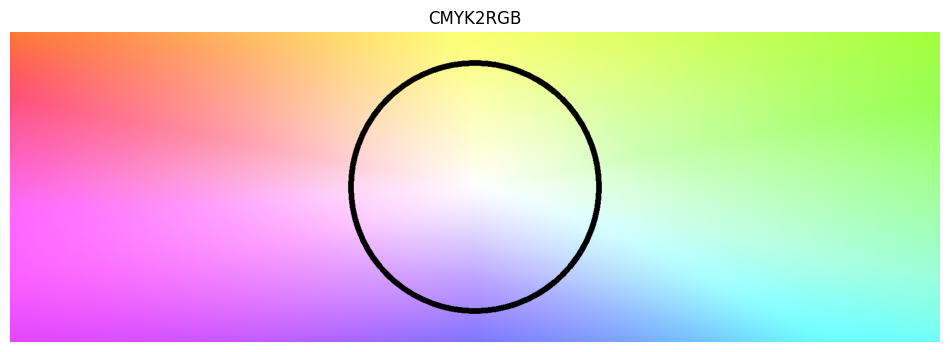

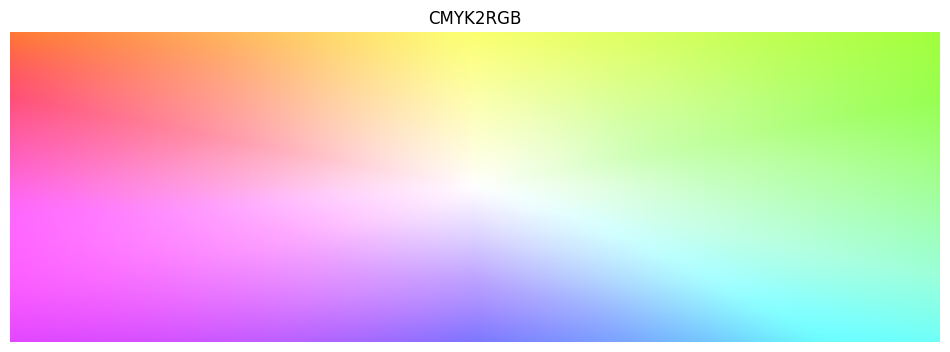

In [230]:
def show_cmyk_slice(cmyk_slice):
    # cmyk_slice  # 形状为(..., 4)
    # 确保数据类型正确
    if cmyk_slice.dtype != np.uint8:
        if cmyk_slice.max() <= 255.0:
            cmyk_slice = cmyk_slice.astype(np.uint8)
        else:
            cmyk_slice = (cmyk_slice / cmyk_slice.max() * 255).astype(np.uint8)

    # 创建CMYK模式的PIL图像
    cmyk_img = Image.fromarray(cmyk_slice, mode='CMYK')

    # 方法1：转换为RGB后显示
    rgb_img = cmyk_img.convert('RGB')
    plt.figure(figsize=(12, 8))
    plt.imshow(rgb_img)
    plt.title("CMYK2RGB")
    plt.axis('off')
    plt.show()
    
show_cmyk_slice(volume_icc[0])
show_cmyk_slice(volume_icc[10])
    

In [231]:
import numpy as np
from tqdm import tqdm

volume_icc_halftone = np.zeros((volume_icc.shape[0], volume_icc.shape[1], volume_icc.shape[2]))

def white_weight_func(cmyk_sum):
    # return np.exp(-cmyk_sum * 5)  # 指数衰减函数
    white_threshold = 0.8*255  # 可调整的阈值
    white_weight = np.maximum(0, white_threshold - cmyk_sum)
    return white_weight

for i in tqdm(range(volume_icc.shape[0]), desc="halftone sampling..."):
    cmyk_slice = volume_icc[i]
    # 创建采样结果数组
    height, width, channels = cmyk_slice.shape
    sampled_image = np.zeros((height, width), dtype=np.uint8)
    # 确保所有值都是非负的
    cmyk_values = np.maximum(cmyk_slice, 0)
    # 计算CMYK的总和
    cmyk_sum = np.sum(cmyk_values, axis=-1)
    
    #! 检查是否在前10层或最后10层
    is_boundary_layer = (i < 20) or (i >= volume_icc.shape[0] - 20)
    # is_boundary_layer=False
    
    
    if is_boundary_layer:
        # 前10层和最后10层：只使用CMYK通道，不使用白色
        cmyk_w_values = cmyk_values  # 只有4个通道 [C, M, Y, K]
        
        # 计算总和（只包括CMYK通道）
        totals = np.sum(cmyk_w_values, axis=-1)
        
        # 生成随机数数组
        r = np.random.random((height, width)) * totals
        
        # 计算累积和
        cumulative = np.cumsum(cmyk_w_values, axis=-1)
        
        # 初始化采样结果为全0
        sampled_image = np.zeros((height, width), dtype=np.uint8)
        for k in range(1, 5):  # 从通道1开始，因为通道0是默认值
            sampled_image = np.where(r >= cumulative[:, :, k-1], k, sampled_image)
        
        # 处理总和为0的情况（将其分配为5，即白色）
        zero_totals = (totals == 0)
        if np.any(zero_totals):
            # 对于总和为0的像素，分配为5（白色）
            sampled_image = np.where(zero_totals, 5, sampled_image)

    else:
        # 中间层：使用CMYK和白色通道
        # 定义白色通道的权重
        white_weight = white_weight_func(cmyk_sum)
        
        # 创建包含白色通道的5通道数组 [C, M, Y, K, White]
        cmyk_w_values = np.zeros((height, width, 5))
        cmyk_w_values[:, :, :4] = cmyk_values  # 前4个通道是CMYK
        cmyk_w_values[:, :, 4] = white_weight  # 第5个通道是白色
        
        # 计算总和（包括白色通道）
        totals = np.sum(cmyk_w_values, axis=-1)
        
        # 生成随机数数组 (0到1之间的随机数乘以总和)
        r = np.random.random((height, width)) * totals
        
        # 计算累积和
        cumulative = np.cumsum(cmyk_w_values, axis=-1)
        
        # 初始化采样结果为全0
        sampled_image = np.zeros((height, width), dtype=np.uint8)
        for k in range(1, 6):  # 从通道1开始，因为通道0是默认值
            sampled_image = np.where(r >= cumulative[:, :, k-1], k, sampled_image)
        
        # 处理总和为0的情况
        zero_totals = (totals == 0)
        if np.any(zero_totals):
            print(f"Layer {i}: ZERO!!")
    
    volume_icc_halftone[i] = sampled_image


halftone sampling...: 100%|██████████| 357/357 [00:27<00:00, 13.16it/s]


In [165]:
# 可视化采样结果
def previewHalftone(sampled_image, cmyk_slice): 
    # 更新颜色映射以包含白色
    cmap = plt.cm.colors.ListedColormap(['cyan', 'magenta', 'yellow', 'black', 'white', "grey"])
    bounds = [0, 1, 2, 3, 4, 5, 6]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(12, 8))
    plt.imshow(sampled_image, cmap=cmap, norm=norm)
    plt.colorbar(ticks=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], label='')
    plt.clim(-0.5, 5.5)
    plt.title('CMYKW Halftone')
    plt.axis('off')
    plt.show()

    # 显示原始CMYK值和计算的白色通道值的分布
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    channel_names = ['C (River)', 'M (Flower)', 'Y (Yellow)', 'K (Black)', "White"]

    # 原始CMYK切片
    cmyk_values = np.maximum(cmyk_slice, 0)

    # 计算CMYK的总和
    cmyk_sum = np.sum(cmyk_values, axis=-1)

    # 显示CMYK通道
    for i in range(4):
        im = axes[i].imshow(cmyk_values[:, :, i], cmap='viridis')
        axes[i].set_title(f'{channel_names[i]}')
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i])

    # 显示白色通道
    white_weight = white_weight_func(cmyk_sum)
    im = axes[4].imshow(white_weight, cmap='viridis')
    axes[4].set_title(f'{channel_names[4]}')
    axes[4].axis('off')
    plt.colorbar(im, ax=axes[4])

    plt.tight_layout()
    plt.show()


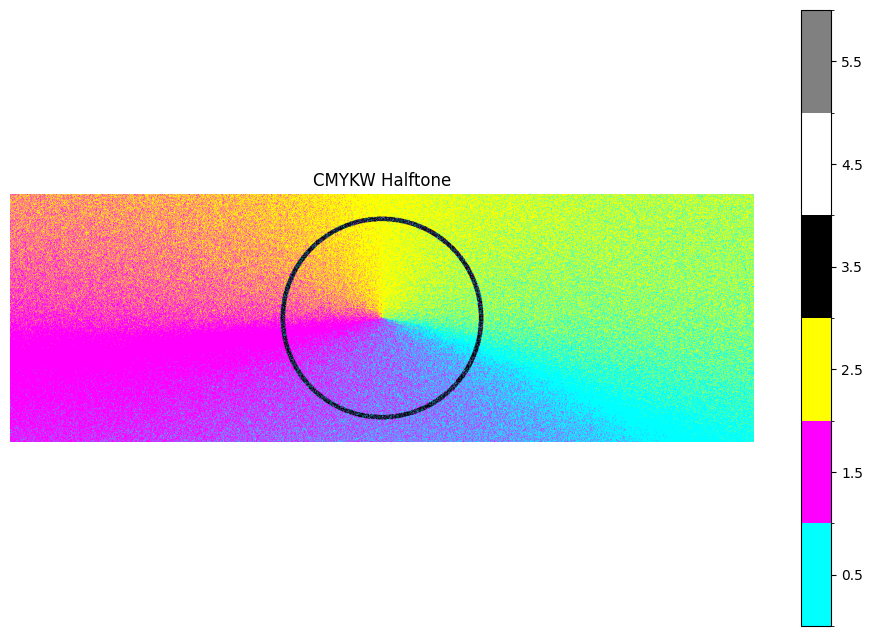

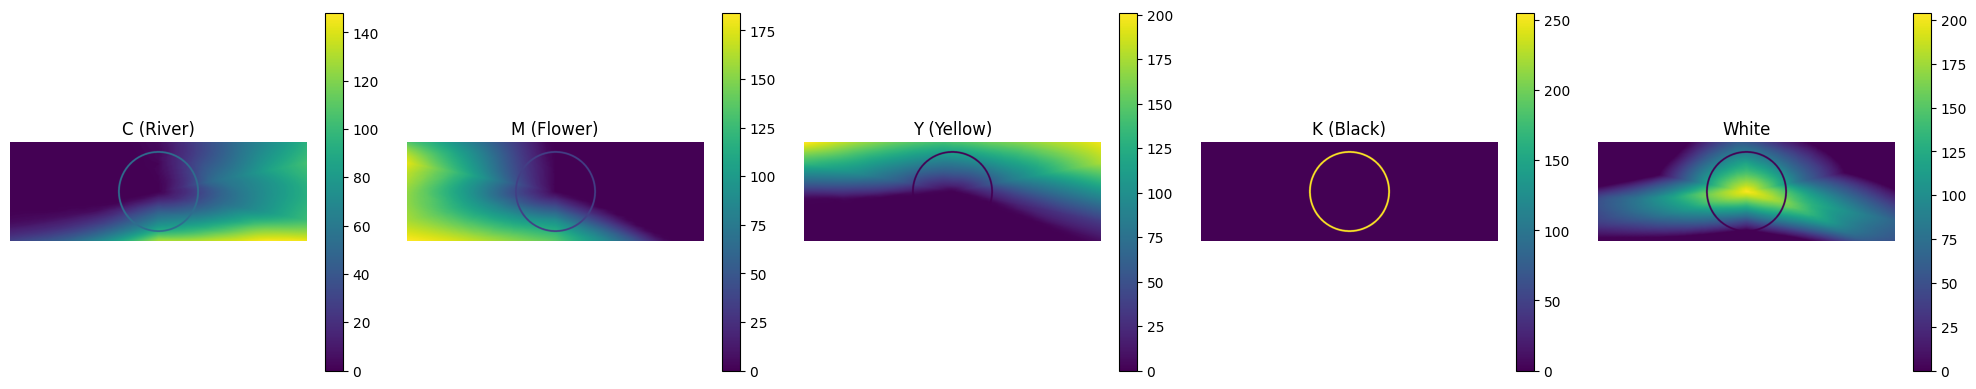

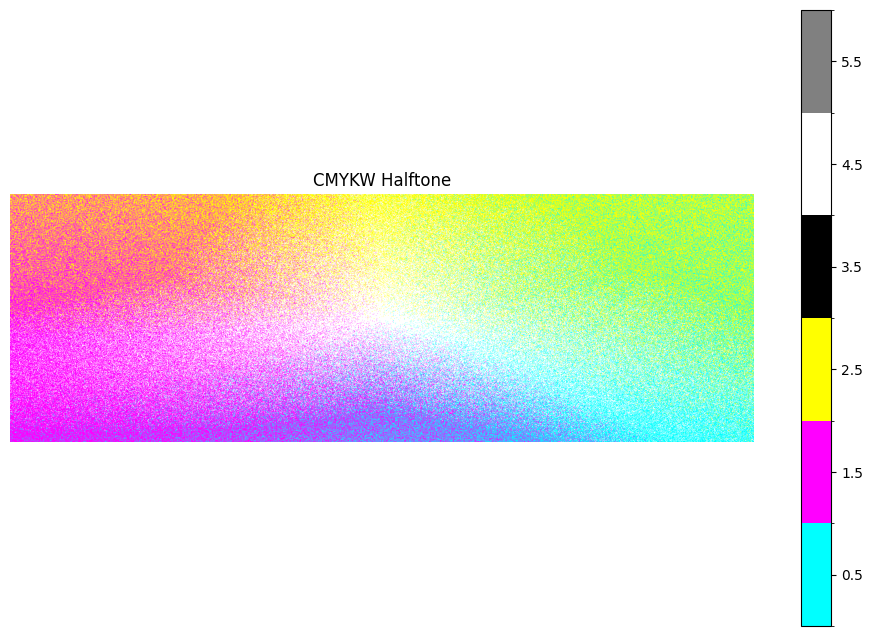

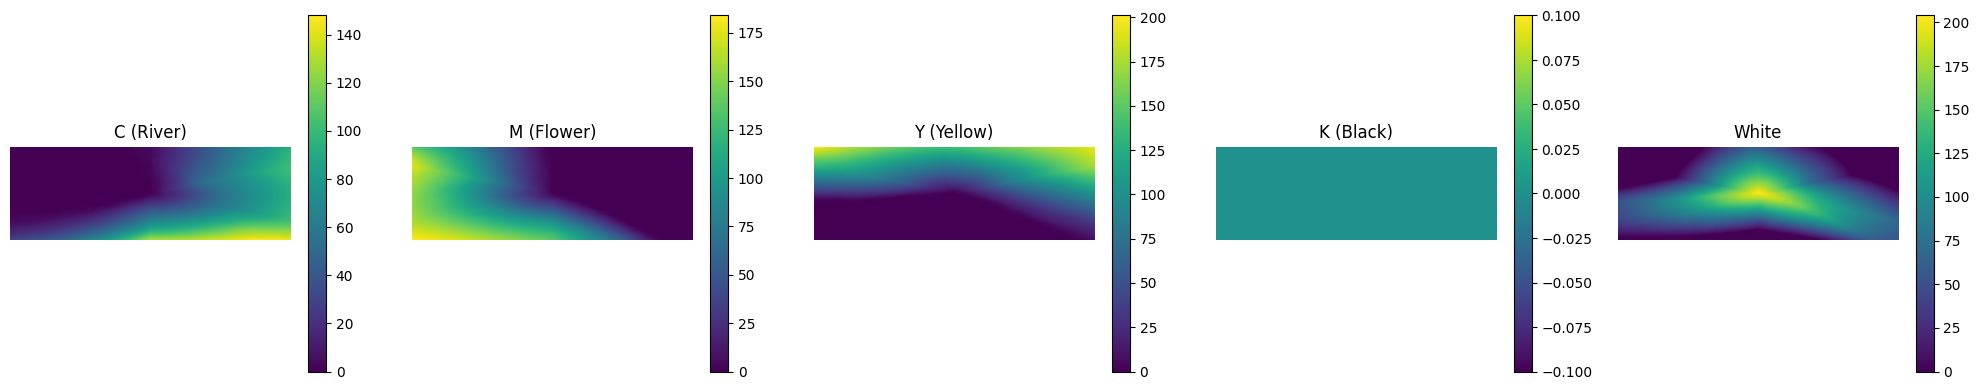

In [232]:
previewHalftone(volume_icc_halftone[0], volume_icc[0])
previewHalftone(volume_icc_halftone[20], volume_icc[20])


In [233]:
# 切圆形
z_length = 0.014
y_length = z_length * 2
x_length = y_length * 3
for i in tqdm(range(volume_icc_halftone.shape[0]), desc="cutting circle..."):
    slice = volume_icc_halftone[i].copy()
    x_center = slice.shape[1]//2
    y_center = slice.shape[0]//2
    # 计算坐标到中心的dx,dy
    y_coords, x_coords = np.ogrid[:slice.shape[0], :slice.shape[1]]
    dist_from_center = np.sqrt(((x_coords - x_center)*y_length)**2 + ((y_coords - y_center)*x_length)**2)
    # 设置距离中心50mm以外的像素为5
    slice[dist_from_center > 25] = 5
    volume_icc_halftone[i] = slice

cutting circle...: 100%|██████████| 357/357 [00:01<00:00, 300.21it/s]


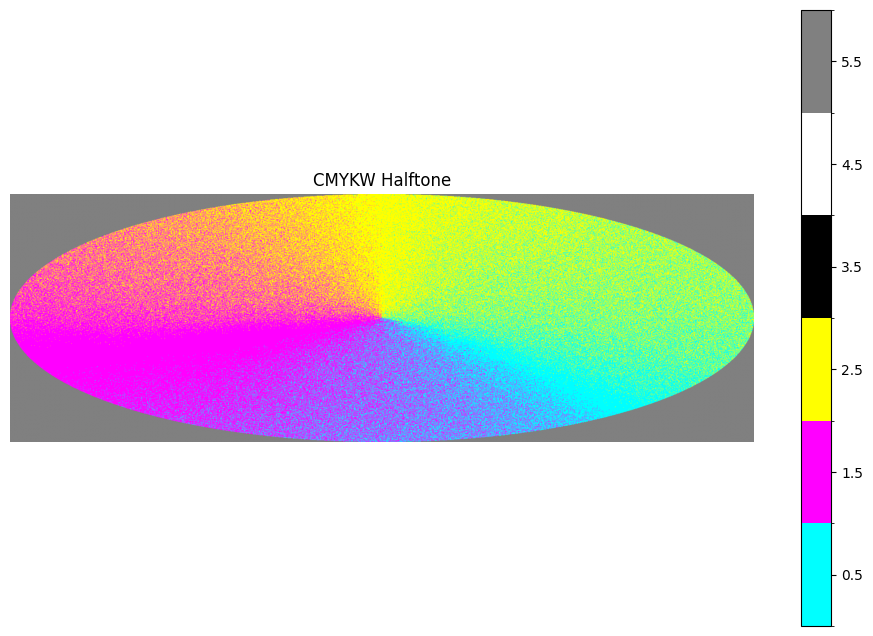

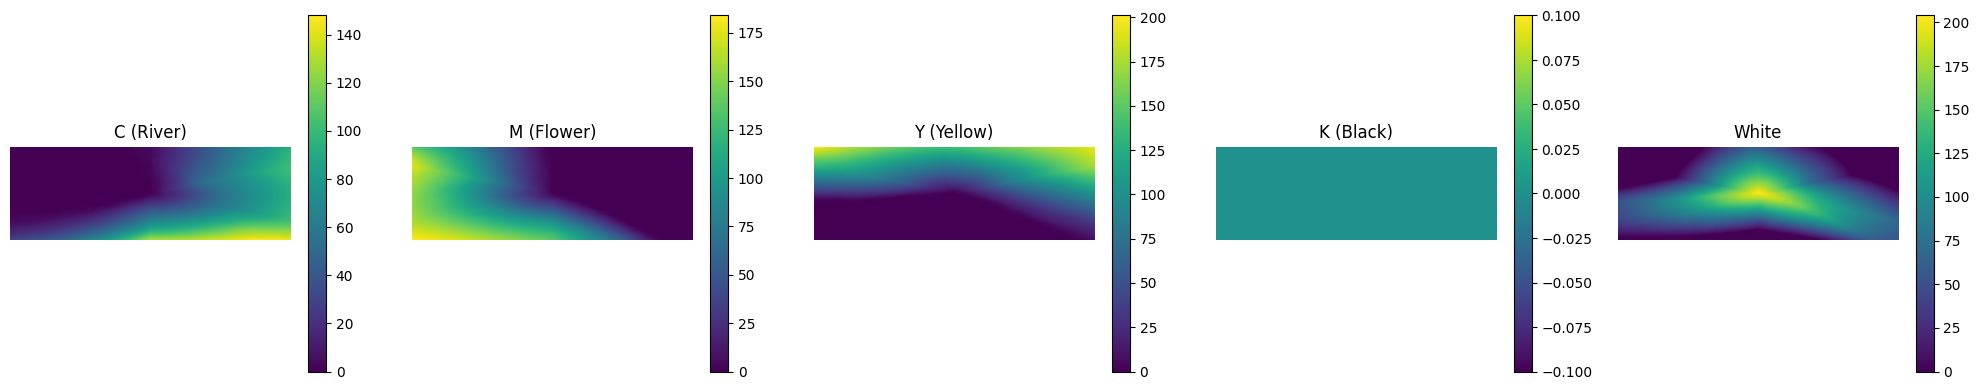

In [234]:
previewHalftone(volume_icc_halftone[-1], volume_icc[-1])


In [235]:
# SaveFolder = "ColorWheel/volumeWheel/colorSampleHalftone"
# SaveFolder = "ColorWheel/volumeWheel/colorSampleHalftone3Dv1"
SaveFolder = "ColorWheel/volumeWheel/colorSampleHalftone3Dv3"
# 确保目标目录存在
os.makedirs(SaveFolder, exist_ok=True)
# 删除其中所有文件
for file in os.listdir(SaveFolder):
    os.remove(f"{SaveFolder}/{file}")

# 创建自定义颜色映射: 0=C, 1=M, 2=Y, 3=K, 4=W, 5=透明
# 使用CMYK对应的RGB值
colors = [
    [0, 1, 1],    # C - 青色 (RGB: 0, 255, 255)
    [1, 0, 1],    # M - 品红 (RGB: 255, 0, 255)
    [1, 1, 0],    # Y - 黄色 (RGB: 255, 255, 0)
    [0, 0, 0],    # K - 黑色 (RGB: 0, 0, 0)
    [1, 1, 1],    # W - 白色 (RGB: 255, 255, 255)
    [1, 1, 1, 0]  # 透明 (带alpha通道的白色)
]

# 创建自定义颜色映射
cmap = ListedColormap(colors[:5])  # 不包括透明色，我们会单独处理透明度

for i in tqdm(range(volume_icc_halftone.shape[0]), desc="saving png slices..."):
    slice_data = volume_icc_halftone[i].copy()
    
    # 创建RGBA图像
    rgba_image = np.ones((slice_data.shape[0], slice_data.shape[1], 4))
    
    # 设置RGB颜色
    for val in range(5):  # 处理0-4的值
        mask = (slice_data == val)
        rgba_image[mask, 0] = colors[val][0]
        rgba_image[mask, 1] = colors[val][1]
        rgba_image[mask, 2] = colors[val][2]
    
    # 设置透明度 - 只有值为5的像素是透明的
    rgba_image[slice_data == 5, 3] = 0  # 设置透明度为0
    
    # 保存图像
    plt.imsave(f"{SaveFolder}/{i:04d}.png", rgba_image)

saving png slices...:   0%|          | 0/357 [00:00<?, ?it/s]

saving png slices...: 100%|██████████| 357/357 [01:12<00:00,  4.90it/s]


In [236]:
# 压缩文件夹到zip
import os


cmd="cd /home/arno/Projects/Pint3D/print_ngp/Mesh2Volume/ColorWheel && zip -r 20250324_volumeWheel.zip volumeWheel"
os.system(cmd)

  adding: volumeWheel/ (stored 0%)
  adding: volumeWheel/colorSampleHalftone3Dv1/ (stored 0%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0027.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0001.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0279.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0170.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0099.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0345.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0102.png (deflated 0%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0041.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0232.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0171.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0176.png (deflated 1%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0158.png (deflated 0%)
  adding: volumeWheel/colorSampleHalftone3Dv1/0180.png (deflated 1%)
  adding:

0